# DQN baseline record

Presentation and analysis notebook for the DQN baseline and reward comparison.
Experiment execution is delegated to the DQN runner package; this notebook passes configuration and reads saved artifacts.


# DQN Baseline Runner

This notebook launches fresh DQN baselines on `matlab_env_python_replica` and renders the saved baseline plots inline.

Default scenario for this notebook:
- `30 s` episode duration
- `10 s` skin-to-fat switch
- midpoint reset
- force input `5 N` amplitude, `15 N` bias, `6 rad/s`
- stroke limit handled with mechanical clamp mode
- both FE modes: `switched_dynamics` and `gui_skin_locked`


## Reward Coefficient Check

In [1]:
import importlib
import sys
from pathlib import Path

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    for root in (candidate, candidate / 'TeleopWithRL'):
        if (root / 'matlab_env_python_replica').exists() and (root / 'notebooks' / '_teleop_nb.py').exists():
            for path_to_add in (root.parent, root):
                if str(path_to_add) not in sys.path:
                    sys.path.insert(0, str(path_to_add))
            break
    else:
        continue
    break
else:
    raise RuntimeError('Could not find TeleopWithRL notebook root.')

from notebooks._teleop_nb import run_notebook_command, show_rows
import TeleopWithRL.matlab_env_python_replica.common.rewarding as rewarding
rewarding = importlib.reload(rewarding)

base_reward_variant = rewarding.baseline_reward_variant()
equal_gradient_variant = rewarding.equal_gradient_reward_variant()
normalized_force_shape_variant = rewarding.normalized_force_shape_reward_variant()
normalized_legacy_transparency_variant = rewarding.normalized_legacy_transparency_reward_variant()

reward_candidates = [
    base_reward_variant,
    equal_gradient_variant,
    normalized_force_shape_variant,
    normalized_legacy_transparency_variant,
]
SELECTED_REWARD_VARIANT = equal_gradient_variant.name
normalized_error_levels = [0.25, 0.50, 1.00]

show_rows(
    [
        {
            'name': variant.name,
            'track_w': variant.tracking_weight,
            'track_scale_m': variant.tracking_scale_m,
            'vel_w': variant.velocity_weight,
            'vel_scale_mps': variant.velocity_scale_mps,
            'trans_w': variant.transparency_weight,
            'trans_scale_w': variant.transparency_scale_w,
            'force_w': variant.force_diff_weight,
            'force_scale_n': variant.force_diff_scale_n,
            'jerk_w': variant.jerk_weight if variant.use_jerk else 0.0,
            'jerk_scale_v': variant.jerk_scale_v,
            'effort_w': variant.effort_weight,
            'te_fail_penalty': variant.tracking_error_fail_penalty,
        }
        for variant in reward_candidates
    ],
    title='Reward coefficient candidates',
    max_rows=10,
)

show_rows(
    [
        {
            'name': variant.name,
            'normalized_error': z,
            'dR_d_track_hat': round(-2.0 * float(variant.tracking_weight) * z, 3),
            'dR_d_vel_hat': round(-2.0 * float(variant.velocity_weight) * z, 3),
            'dR_d_trans_hat': round(-2.0 * float(variant.transparency_weight) * z, 3),
            'dR_d_force_hat': round(-2.0 * float(variant.force_diff_weight) * z, 3),
            'dR_d_jerk_hat': round(-2.0 * float(variant.jerk_weight if variant.use_jerk else 0.0) * z, 3),
        }
        for variant in reward_candidates
        for z in normalized_error_levels
    ],
    title='Normalized reward gradient check by term',
    max_rows=20,
)

print(f'Selected reward variant for this run: {SELECTED_REWARD_VARIANT}')


### Reward coefficient candidates

name,track_w,track_scale_m,vel_w,vel_scale_mps,trans_w,trans_scale_w,force_w,force_scale_n,jerk_w,jerk_scale_v,effort_w,te_fail_penalty
baseline_cfg,40.0,0.1375,0.0,1.0,5.0,20.0,0.0,1.0,0.0,1.0,0.01,1000.0
eqgrad_t40_tr40_nojerk,40.0,0.1375,0.0,1.0,40.0,20.0,0.0,1.0,0.0,1.0,0.01,1000.0
norm_force_shape_v1,1.0,0.275,0.5,3.0,0.0,60.0,1.0,25.0,0.05,10.0,0.0,1000.0
norm_legacy_trans_v1,1.0,0.275,0.5,3.0,1.0,60.0,0.0,25.0,0.05,10.0,0.0,1000.0


### Normalized reward gradient check by term

name,normalized_error,dR_d_track_hat,dR_d_vel_hat,dR_d_trans_hat,dR_d_force_hat,dR_d_jerk_hat
baseline_cfg,0.25,-20.0,-0.0,-2.5,-0.0,-0.0
baseline_cfg,0.5,-40.0,-0.0,-5.0,-0.0,-0.0
baseline_cfg,1.0,-80.0,-0.0,-10.0,-0.0,-0.0
eqgrad_t40_tr40_nojerk,0.25,-20.0,-0.0,-20.0,-0.0,-0.0
eqgrad_t40_tr40_nojerk,0.5,-40.0,-0.0,-40.0,-0.0,-0.0
eqgrad_t40_tr40_nojerk,1.0,-80.0,-0.0,-80.0,-0.0,-0.0
norm_force_shape_v1,0.25,-0.5,-0.25,-0.0,-0.5,-0.025
norm_force_shape_v1,0.5,-1.0,-0.5,-0.0,-1.0,-0.05
norm_force_shape_v1,1.0,-2.0,-1.0,-0.0,-2.0,-0.1
norm_legacy_trans_v1,0.25,-0.5,-0.25,-0.5,-0.0,-0.025


Selected reward variant for this run: eqgrad_t40_tr40_nojerk


## Reward Series Preset

Use the next code cell to queue the two DQN reward experiments and run them one after the other with the normal DQN run cell.


### Run Both Reward Experiments in Series


In [2]:
REWARD_VARIANT_SERIES = [
    'norm_force_shape_v1',
    'norm_legacy_trans_v1',
]
SUMMARY_REWARD_VARIANT = REWARD_VARIANT_SERIES[-1]

print('Serial reward run order:')
for idx, reward_name in enumerate(REWARD_VARIANT_SERIES, start=1):
    print(f'{idx}. {reward_name}')
print(f'Summary and plot cells will point to: {SUMMARY_REWARD_VARIANT}')
print('Run the normal `## DQN Run Config` cell next, then the normal run cell.')


Serial reward run order:
1. norm_force_shape_v1
2. norm_legacy_trans_v1
Summary and plot cells will point to: norm_legacy_trans_v1
Run the normal `## DQN Run Config` cell next, then the normal run cell.


## DQN Run Config

In [3]:
import subprocess
import sys
from pathlib import Path

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    for root in (candidate, candidate / 'TeleopWithRL'):
        if (root / 'matlab_env_python_replica').exists() and (root / 'notebooks' / '_teleop_nb.py').exists():
            for path_to_add in (root.parent, root):
                if str(path_to_add) not in sys.path:
                    sys.path.insert(0, str(path_to_add))
            break
    else:
        continue
    break
else:
    raise RuntimeError('Could not find TeleopWithRL notebook root.')

from notebooks._teleop_nb import load_json, repo_paths, run_notebook_command, show_image, show_markdown, show_rows

P = repo_paths()
REPO = P['repo']
WORKSPACE = REPO.parent
DQN_RESULTS = P['dqn_results']

selected_reward_variant = str(globals().get('SELECTED_REWARD_VARIANT', 'eqgrad_t40_tr40_nojerk'))
reward_variants_to_run = list(globals().get('REWARD_VARIANT_SERIES', []))
if not reward_variants_to_run:
    reward_variants_to_run = [selected_reward_variant]
summary_reward_variant = str(globals().get('SUMMARY_REWARD_VARIANT', reward_variants_to_run[-1]))

reward_tag_aliases = {
    'baseline_cfg': 'base',
    'eqgrad_t40_tr40_nojerk': 'eqg40',
    'norm_force_shape_v1': 'nfs1',
    'norm_legacy_trans_v1': 'nlt1',
}

def build_run_spec(reward_variant):
    reward_tag = reward_tag_aliases.get(
        reward_variant,
        ''.join(ch for ch in reward_variant if ch.isalnum())[:12].lower(),
    )
    cfg = {
        'study_name': f'dqn_30s10s_mid_5A15B_w6_clp_{reward_tag}_01',
        'env_mode': 'changing_skin_fat',
        'episode_duration_s': 30.0,
        'env_switch_time_s': 10.0,
        'reset_position_mode': 'midpoint',
        'stroke_limit_mode': 'clamp',
        'force_amp_N': 5.0,
        'force_bias_N': 15.0,
        'force_freq_rad_s': 6.0,
        'force_phase_rad': 0.0,
        'force_waveform': 'sine',
        'reward_variant': reward_variant,
        'dqn_episodes': 2500,
        'dqn_parallel_envs': 8,
        'test_episodes': 100,
        'seed': 42,
        'parallel_workers': 1,
        'worker_torch_threads': 1,
        'skip_existing': True,
        'resume': False,
        'run_parallel': False,
        'disable_stroke_limit': False,
    }
    run_roots = {
        mode: DQN_RESULTS / mode / f"{cfg['study_name']}_{mode}" / '00b' / 'dqn'
        for mode in ('dyn', 'gui')
    }
    cmd = [
        sys.executable,
        '-m',
        'TeleopWithRL.matlab_env_python_replica.dqn.scripts.run_baselines_both_fe',
        '--study-name', cfg['study_name'],
        '--env-mode', cfg['env_mode'],
        '--episode-duration', str(cfg['episode_duration_s']),
        '--env-switch-time', str(cfg['env_switch_time_s']),
        '--reset-position-mode', cfg['reset_position_mode'],
        '--stroke-limit-mode', cfg['stroke_limit_mode'],
        '--force-amp', str(cfg['force_amp_N']),
        '--force-bias', str(cfg['force_bias_N']),
        '--force-freq-rad', str(cfg['force_freq_rad_s']),
        '--force-phase', str(cfg['force_phase_rad']),
        '--force-waveform', cfg['force_waveform'],
        '--reward-variant', cfg['reward_variant'],
        '--dqn-episodes', str(cfg['dqn_episodes']),
        '--dqn-parallel-envs', str(cfg['dqn_parallel_envs']),
        '--test-episodes', str(cfg['test_episodes']),
        '--seed', str(cfg['seed']),
        '--parallel-workers', str(cfg['parallel_workers']),
        '--worker-torch-threads', str(cfg['worker_torch_threads']),
    ]
    if cfg['skip_existing']:
        cmd.append('--skip-existing')
    if cfg['resume']:
        cmd.append('--resume')
    if cfg['disable_stroke_limit']:
        cmd.append('--disable-stroke-limit')
    if cfg['run_parallel']:
        cmd.append('--run-parallel')
    return {'cfg': cfg, 'run_roots': run_roots, 'cmd': cmd}

RUN_SPECS = [build_run_spec(reward_variant) for reward_variant in reward_variants_to_run]
summary_spec = next(
    (spec for spec in RUN_SPECS if spec['cfg']['reward_variant'] == summary_reward_variant),
    RUN_SPECS[-1],
)

CFG = summary_spec['cfg']
RUN_ROOTS = summary_spec['run_roots']
CMD = summary_spec['cmd']
MODE_LABELS = {
    'dyn': 'switched_dynamics',
    'gui': 'gui_skin_locked',
}

show_rows(
    [
        {
            'order': idx,
            'reward_variant': spec['cfg']['reward_variant'],
            'study_name': spec['cfg']['study_name'],
            'episode_duration_s': spec['cfg']['episode_duration_s'],
            'env_switch_time_s': spec['cfg']['env_switch_time_s'],
            'stroke_limit_mode': spec['cfg']['stroke_limit_mode'],
            'force_amp_N': spec['cfg']['force_amp_N'],
            'force_bias_N': spec['cfg']['force_bias_N'],
            'force_freq_rad_s': spec['cfg']['force_freq_rad_s'],
            'dqn_episodes': spec['cfg']['dqn_episodes'],
            'test_episodes': spec['cfg']['test_episodes'],
            'dyn_run_root': str(spec['run_roots']['dyn']),
            'gui_run_root': str(spec['run_roots']['gui']),
            'command': subprocess.list2cmdline(spec['cmd']),
        }
        for idx, spec in enumerate(RUN_SPECS, start=1)
    ],
    title='DQN baseline run configs',
    max_rows=20,
)
print(f"Summary and plot cells target reward variant: {CFG['reward_variant']}")
print(f'Serial run count: {len(RUN_SPECS)}')


### DQN baseline run configs

order,reward_variant,study_name,episode_duration_s,env_switch_time_s,stroke_limit_mode,force_amp_N,force_bias_N,force_freq_rad_s,dqn_episodes,test_episodes,dyn_run_root,gui_run_root,command
1,norm_force_shape_v1,dqn_30s10s_mid_5A15B_w6_clp_nfs1_01,30.0,10.0,clamp,5.0,15.0,6.0,2500,100,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\dyn\dqn_30s10s_mid_5A15B_w6_clp_nfs1_01_dyn\00b\dqn,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\gui\dqn_30s10s_mid_5A15B_w6_clp_nfs1_01_gui\00b\dqn,"""c:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\.venv\Scripts\python.exe"" -m TeleopWithRL.matlab_env_python_replica.dqn.scripts.run_baselines_both_fe --study-name dqn_30s10s_mid_5A15B_w6_clp_nfs1_01 --env-mode changing_skin_fat --episode-duration 30.0 --env-switch-time 10.0 --reset-position-mode midpoint --stroke-limit-mode clamp --force-amp 5.0 --force-bias 15.0 --force-freq-rad 6.0 --force-phase 0.0 --force-waveform sine --reward-variant norm_force_shape_v1 --dqn-episodes 2500 --dqn-parallel-envs 8 --test-episodes 100 --seed 42 --parallel-workers 1 --worker-torch-threads 1 --skip-existing"
2,norm_legacy_trans_v1,dqn_30s10s_mid_5A15B_w6_clp_nlt1_01,30.0,10.0,clamp,5.0,15.0,6.0,2500,100,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\dyn\dqn_30s10s_mid_5A15B_w6_clp_nlt1_01_dyn\00b\dqn,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\gui\dqn_30s10s_mid_5A15B_w6_clp_nlt1_01_gui\00b\dqn,"""c:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\.venv\Scripts\python.exe"" -m TeleopWithRL.matlab_env_python_replica.dqn.scripts.run_baselines_both_fe --study-name dqn_30s10s_mid_5A15B_w6_clp_nlt1_01 --env-mode changing_skin_fat --episode-duration 30.0 --env-switch-time 10.0 --reset-position-mode midpoint --stroke-limit-mode clamp --force-amp 5.0 --force-bias 15.0 --force-freq-rad 6.0 --force-phase 0.0 --force-waveform sine --reward-variant norm_legacy_trans_v1 --dqn-episodes 2500 --dqn-parallel-envs 8 --test-episodes 100 --seed 42 --parallel-workers 1 --worker-torch-threads 1 --skip-existing"


Summary and plot cells target reward variant: norm_legacy_trans_v1
Serial run count: 2


In [4]:
for idx, spec in enumerate(RUN_SPECS, start=1):
    cfg = spec['cfg']
    cmd = spec['cmd']
    print(f"[{idx}/{len(RUN_SPECS)}] {cfg['reward_variant']} -> {subprocess.list2cmdline(cmd)}")
    completed = run_notebook_command(cmd, cwd=WORKSPACE)
    print(f"[{idx}/{len(RUN_SPECS)}] completed {cfg['reward_variant']} with return code {completed.returncode}.")


[1/2] norm_force_shape_v1 -> "c:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\.venv\Scripts\python.exe" -m TeleopWithRL.matlab_env_python_replica.dqn.scripts.run_baselines_both_fe --study-name dqn_30s10s_mid_5A15B_w6_clp_nfs1_01 --env-mode changing_skin_fat --episode-duration 30.0 --env-switch-time 10.0 --reset-position-mode midpoint --stroke-limit-mode clamp --force-amp 5.0 --force-bias 15.0 --force-freq-rad 6.0 --force-phase 0.0 --force-waveform sine --reward-variant norm_force_shape_v1 --dqn-episodes 2500 --dqn-parallel-envs 8 --test-episodes 100 --seed 42 --parallel-workers 1 --worker-torch-threads 1 --skip-existing
[1/2] completed norm_force_shape_v1 with return code 0.
[2/2] norm_legacy_trans_v1 -> "c:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\.venv\Scripts\python.exe" -m TeleopWithRL.matlab_env_python_replica.dqn.scripts.r

## DQN Numeric Summary

In [5]:
summary_rows = []
metric_rows = []
artifact_rows = []
for mode, run_root in RUN_ROOTS.items():
    summary_path = run_root / 'l' / 'summary.json'
    plots_dir = run_root / 'p'
    artifact_rows.append({'fe_mode': MODE_LABELS[mode], 'summary_json': str(summary_path), 'plots_dir': str(plots_dir)})
    if not summary_path.exists():
        summary_rows.append({'fe_mode': MODE_LABELS[mode], 'status': 'missing', 'run_root': str(run_root)})
        continue
    data = load_json(summary_path)
    reset_options = dict(data.get('reset_options', {}))
    summary_rows.append({
        'fe_mode': MODE_LABELS[mode],
        'label': data.get('label'),
        'tracking_rmse_m': data.get('tracking_rmse_m'),
        'transparency_rmse_w': data.get('transparency_rmse_w'),
        'pre_switch_tracking_rmse_m': data.get('pre_switch_tracking_rmse_m'),
        'post_switch_tracking_rmse_m': data.get('post_switch_tracking_rmse_m'),
        'pre_switch_transparency_rmse_w': data.get('pre_switch_transparency_rmse_w'),
        'post_switch_transparency_rmse_w': data.get('post_switch_transparency_rmse_w'),
        'invalid_episode_rate': data.get('invalid_episode_rate'),
        'episode_duration': data.get('episode_duration'),
        'env_switch_time': data.get('env_switch_time'),
        'force_amp': reset_options.get('force_amp'),
        'force_bias': reset_options.get('force_bias'),
        'force_freq_rad': reset_options.get('force_freq_rad'),
        'reset_position_mode': reset_options.get('reset_position_mode'),
        'state_variant': data.get('state_variant'),
        'reward_variant': data.get('reward_variant'),
        'out_dir': data.get('out_dir'),
    })
    metric_rows.append({
        'fe_mode': MODE_LABELS[mode],
        'track_rmse_mm': round(1000.0 * float(data.get('tracking_rmse_m') or 0.0), 3),
        'transp_rmse_w': round(float(data.get('transparency_rmse_w') or 0.0), 3),
        'pre_track_rmse_mm': round(1000.0 * float(data.get('pre_switch_tracking_rmse_m') or 0.0), 3),
        'post_track_rmse_mm': round(1000.0 * float(data.get('post_switch_tracking_rmse_m') or 0.0), 3),
        'pre_transp_rmse_w': round(float(data.get('pre_switch_transparency_rmse_w') or 0.0), 3),
        'post_transp_rmse_w': round(float(data.get('post_switch_transparency_rmse_w') or 0.0), 3),
        'mean_reward': round(float(data.get('mean_reward') or 0.0), 3),
    })

show_rows(metric_rows, title='DQN rollout RMSE metrics', max_rows=10)
show_rows(summary_rows, title='DQN baseline summaries', max_rows=10)
show_rows(artifact_rows, title='DQN artifact locations', max_rows=10)


### DQN rollout RMSE metrics

fe_mode,track_rmse_mm,transp_rmse_w,pre_track_rmse_mm,post_track_rmse_mm,pre_transp_rmse_w,post_transp_rmse_w,mean_reward
switched_dynamics,47.26,7.52,26.543,54.754,8.224,7.142,-105.207
gui_skin_locked,84.804,50.004,83.922,178.86,50.086,33.566,-1458.635


### DQN baseline summaries

fe_mode,label,tracking_rmse_m,transparency_rmse_w,pre_switch_tracking_rmse_m,post_switch_tracking_rmse_m,pre_switch_transparency_rmse_w,post_switch_transparency_rmse_w,invalid_episode_rate,episode_duration,env_switch_time,force_amp,force_bias,force_freq_rad,reset_position_mode,state_variant,reward_variant,out_dir
switched_dynamics,DQN_baseline_norm_legacy_trans_v1_30s_10s,0.04725982954871827,7.520413487546929,0.026543368469276008,0.05475364854156279,8.22432438484259,7.142490653963674,0.0,30.0,10.0,5.0,15.0,6.0,midpoint,S0_baseline_full10,norm_legacy_trans_v1,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\dyn\dqn_30s10s_mid_5A15B_w6_clp_nlt1_01_dyn\00b\dqn
gui_skin_locked,DQN_baseline_norm_legacy_trans_v1_30s_10s,0.08480422814720684,50.004024056679846,0.08392236336271183,0.17885961996788677,50.08637457627089,33.56565257737253,0.0,30.0,10.0,5.0,15.0,6.0,midpoint,S0_baseline_full10,norm_legacy_trans_v1,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\gui\dqn_30s10s_mid_5A15B_w6_clp_nlt1_01_gui\00b\dqn


### DQN artifact locations

fe_mode,summary_json,plots_dir
switched_dynamics,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\dyn\dqn_30s10s_mid_5A15B_w6_clp_nlt1_01_dyn\00b\dqn\l\summary.json,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\dyn\dqn_30s10s_mid_5A15B_w6_clp_nlt1_01_dyn\00b\dqn\p
gui_skin_locked,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\gui\dqn_30s10s_mid_5A15B_w6_clp_nlt1_01_gui\00b\dqn\l\summary.json,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\dqn_experiments\results\gui\dqn_30s10s_mid_5A15B_w6_clp_nlt1_01_gui\00b\dqn\p


## DQN Plot Gallery

### switched_dynamics

### switched_dynamics: Training metrics

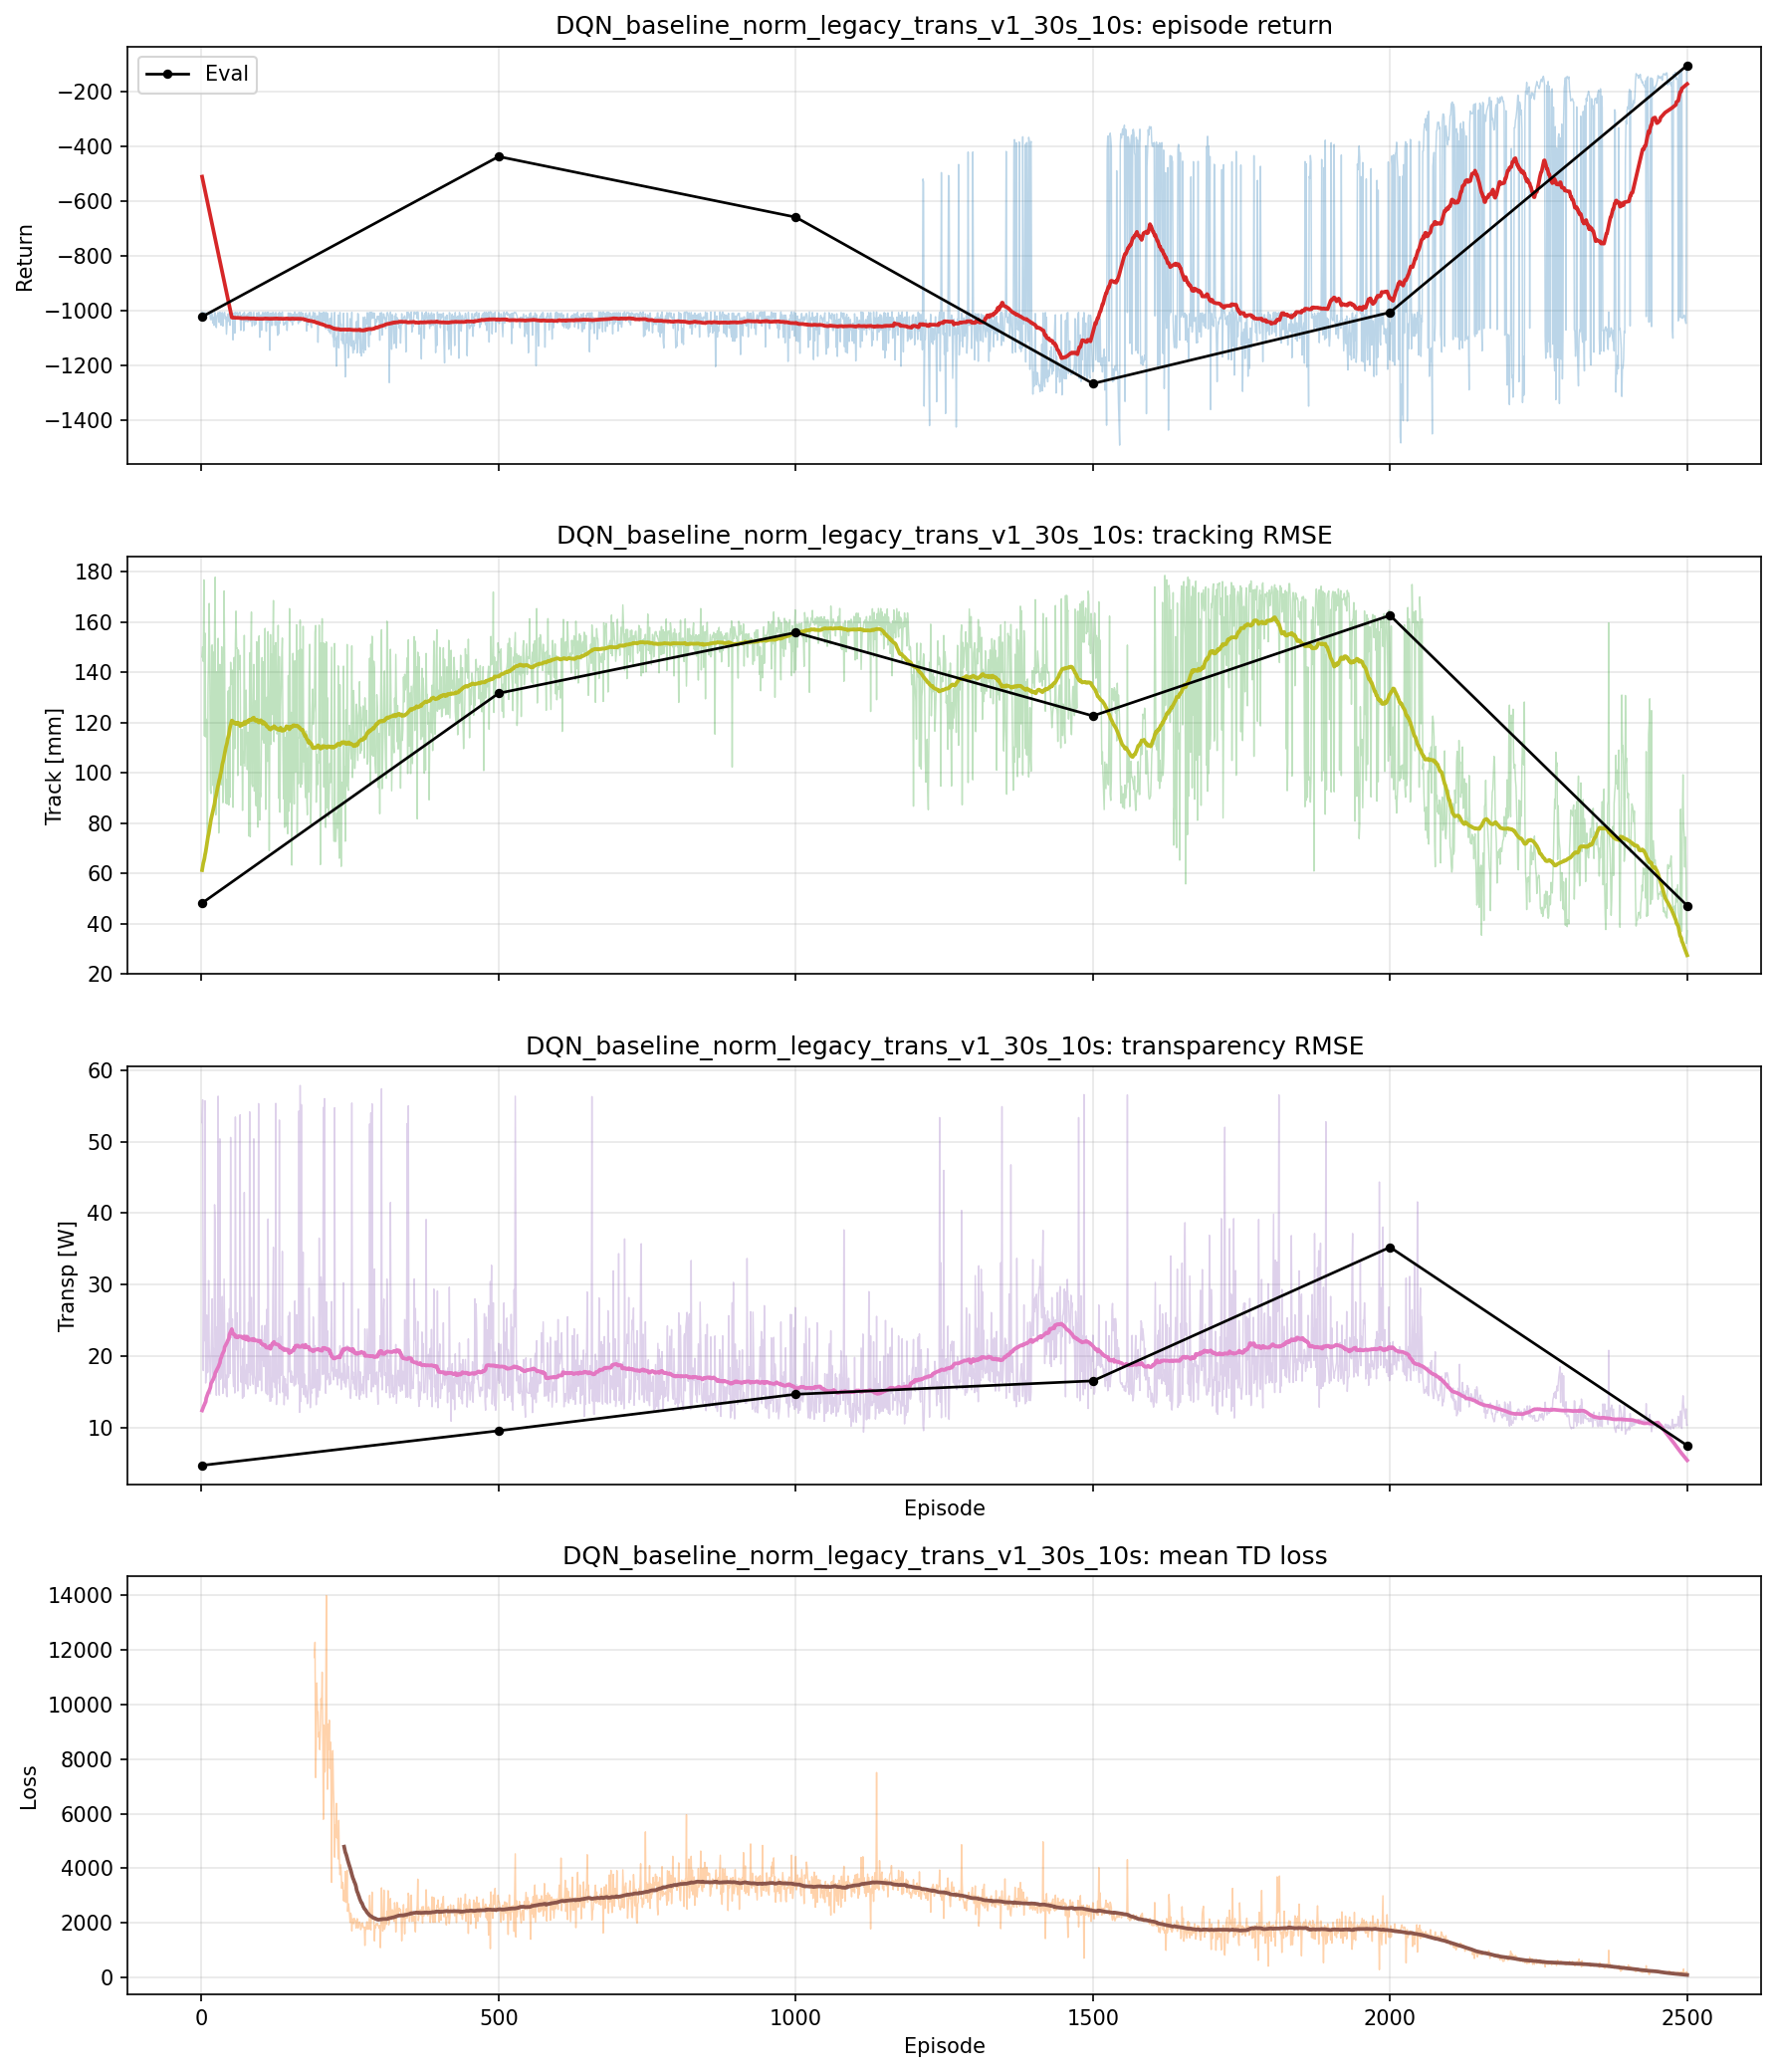

### switched_dynamics: Evaluation roll plot

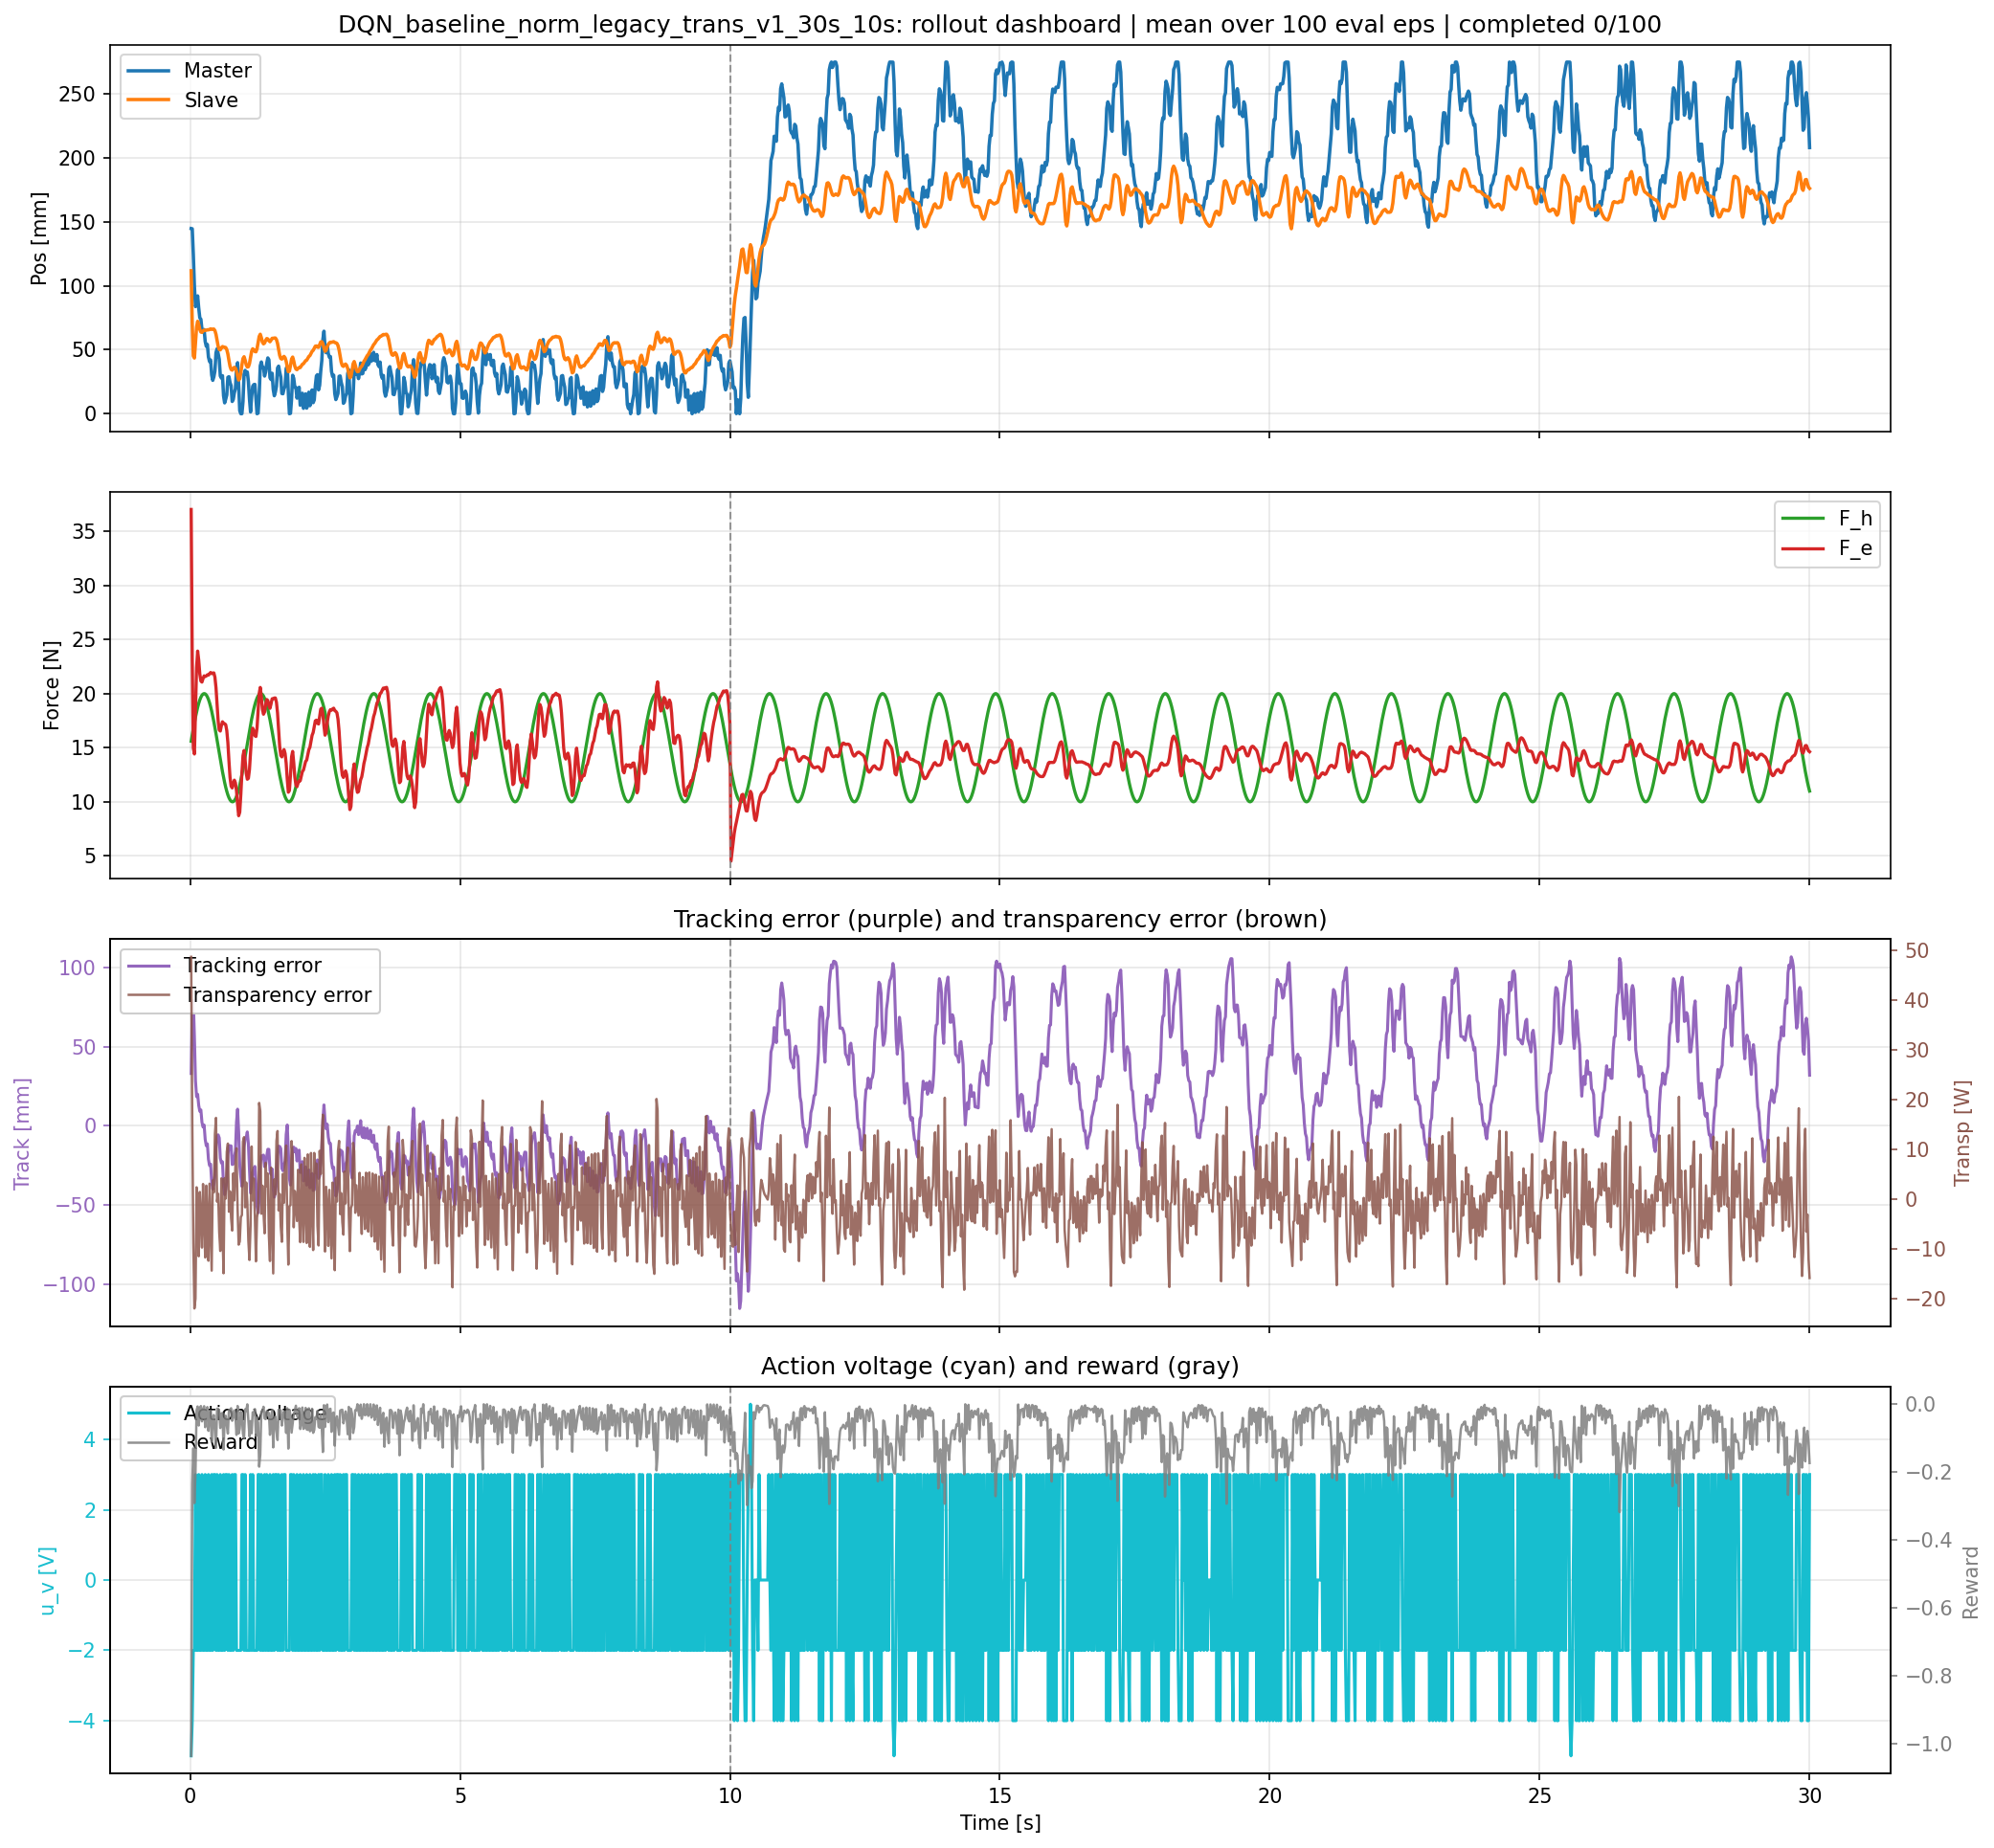

### switched_dynamics: Evaluation action plot

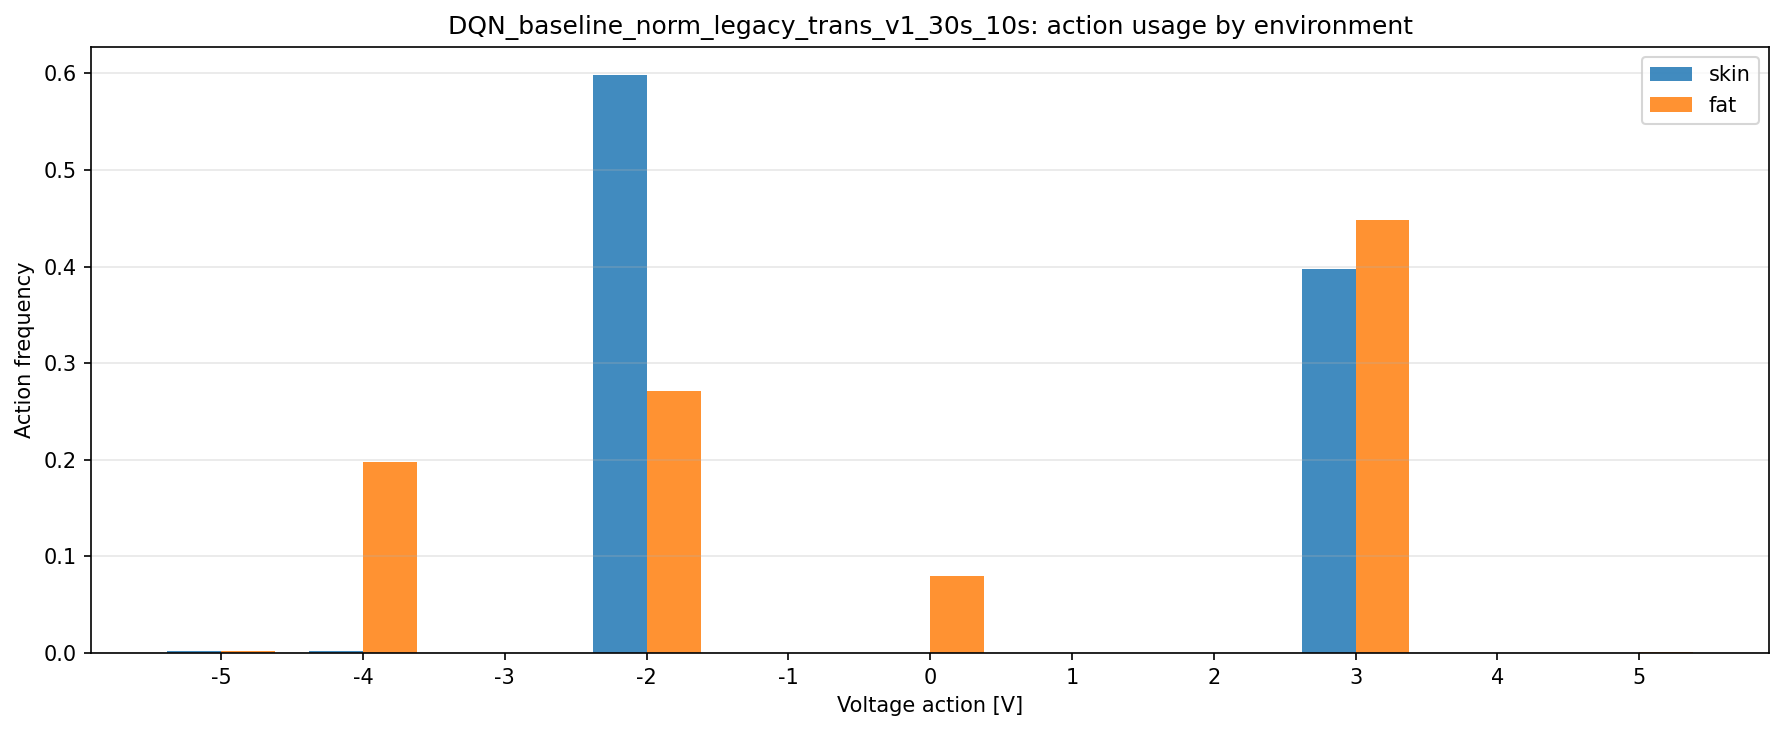

### switched_dynamics: Evaluation trajectory plot

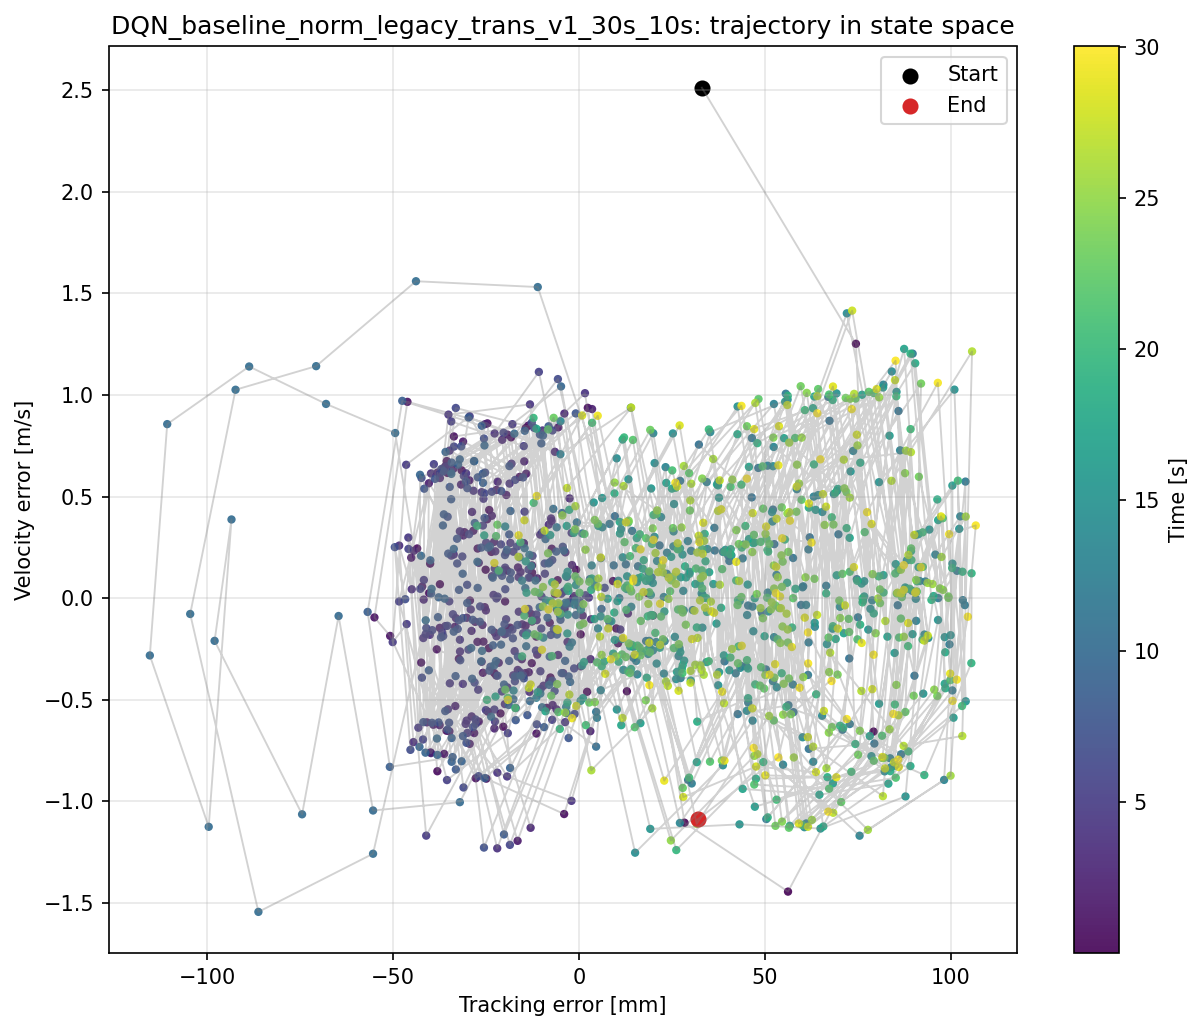

### switched_dynamics: Policy slices

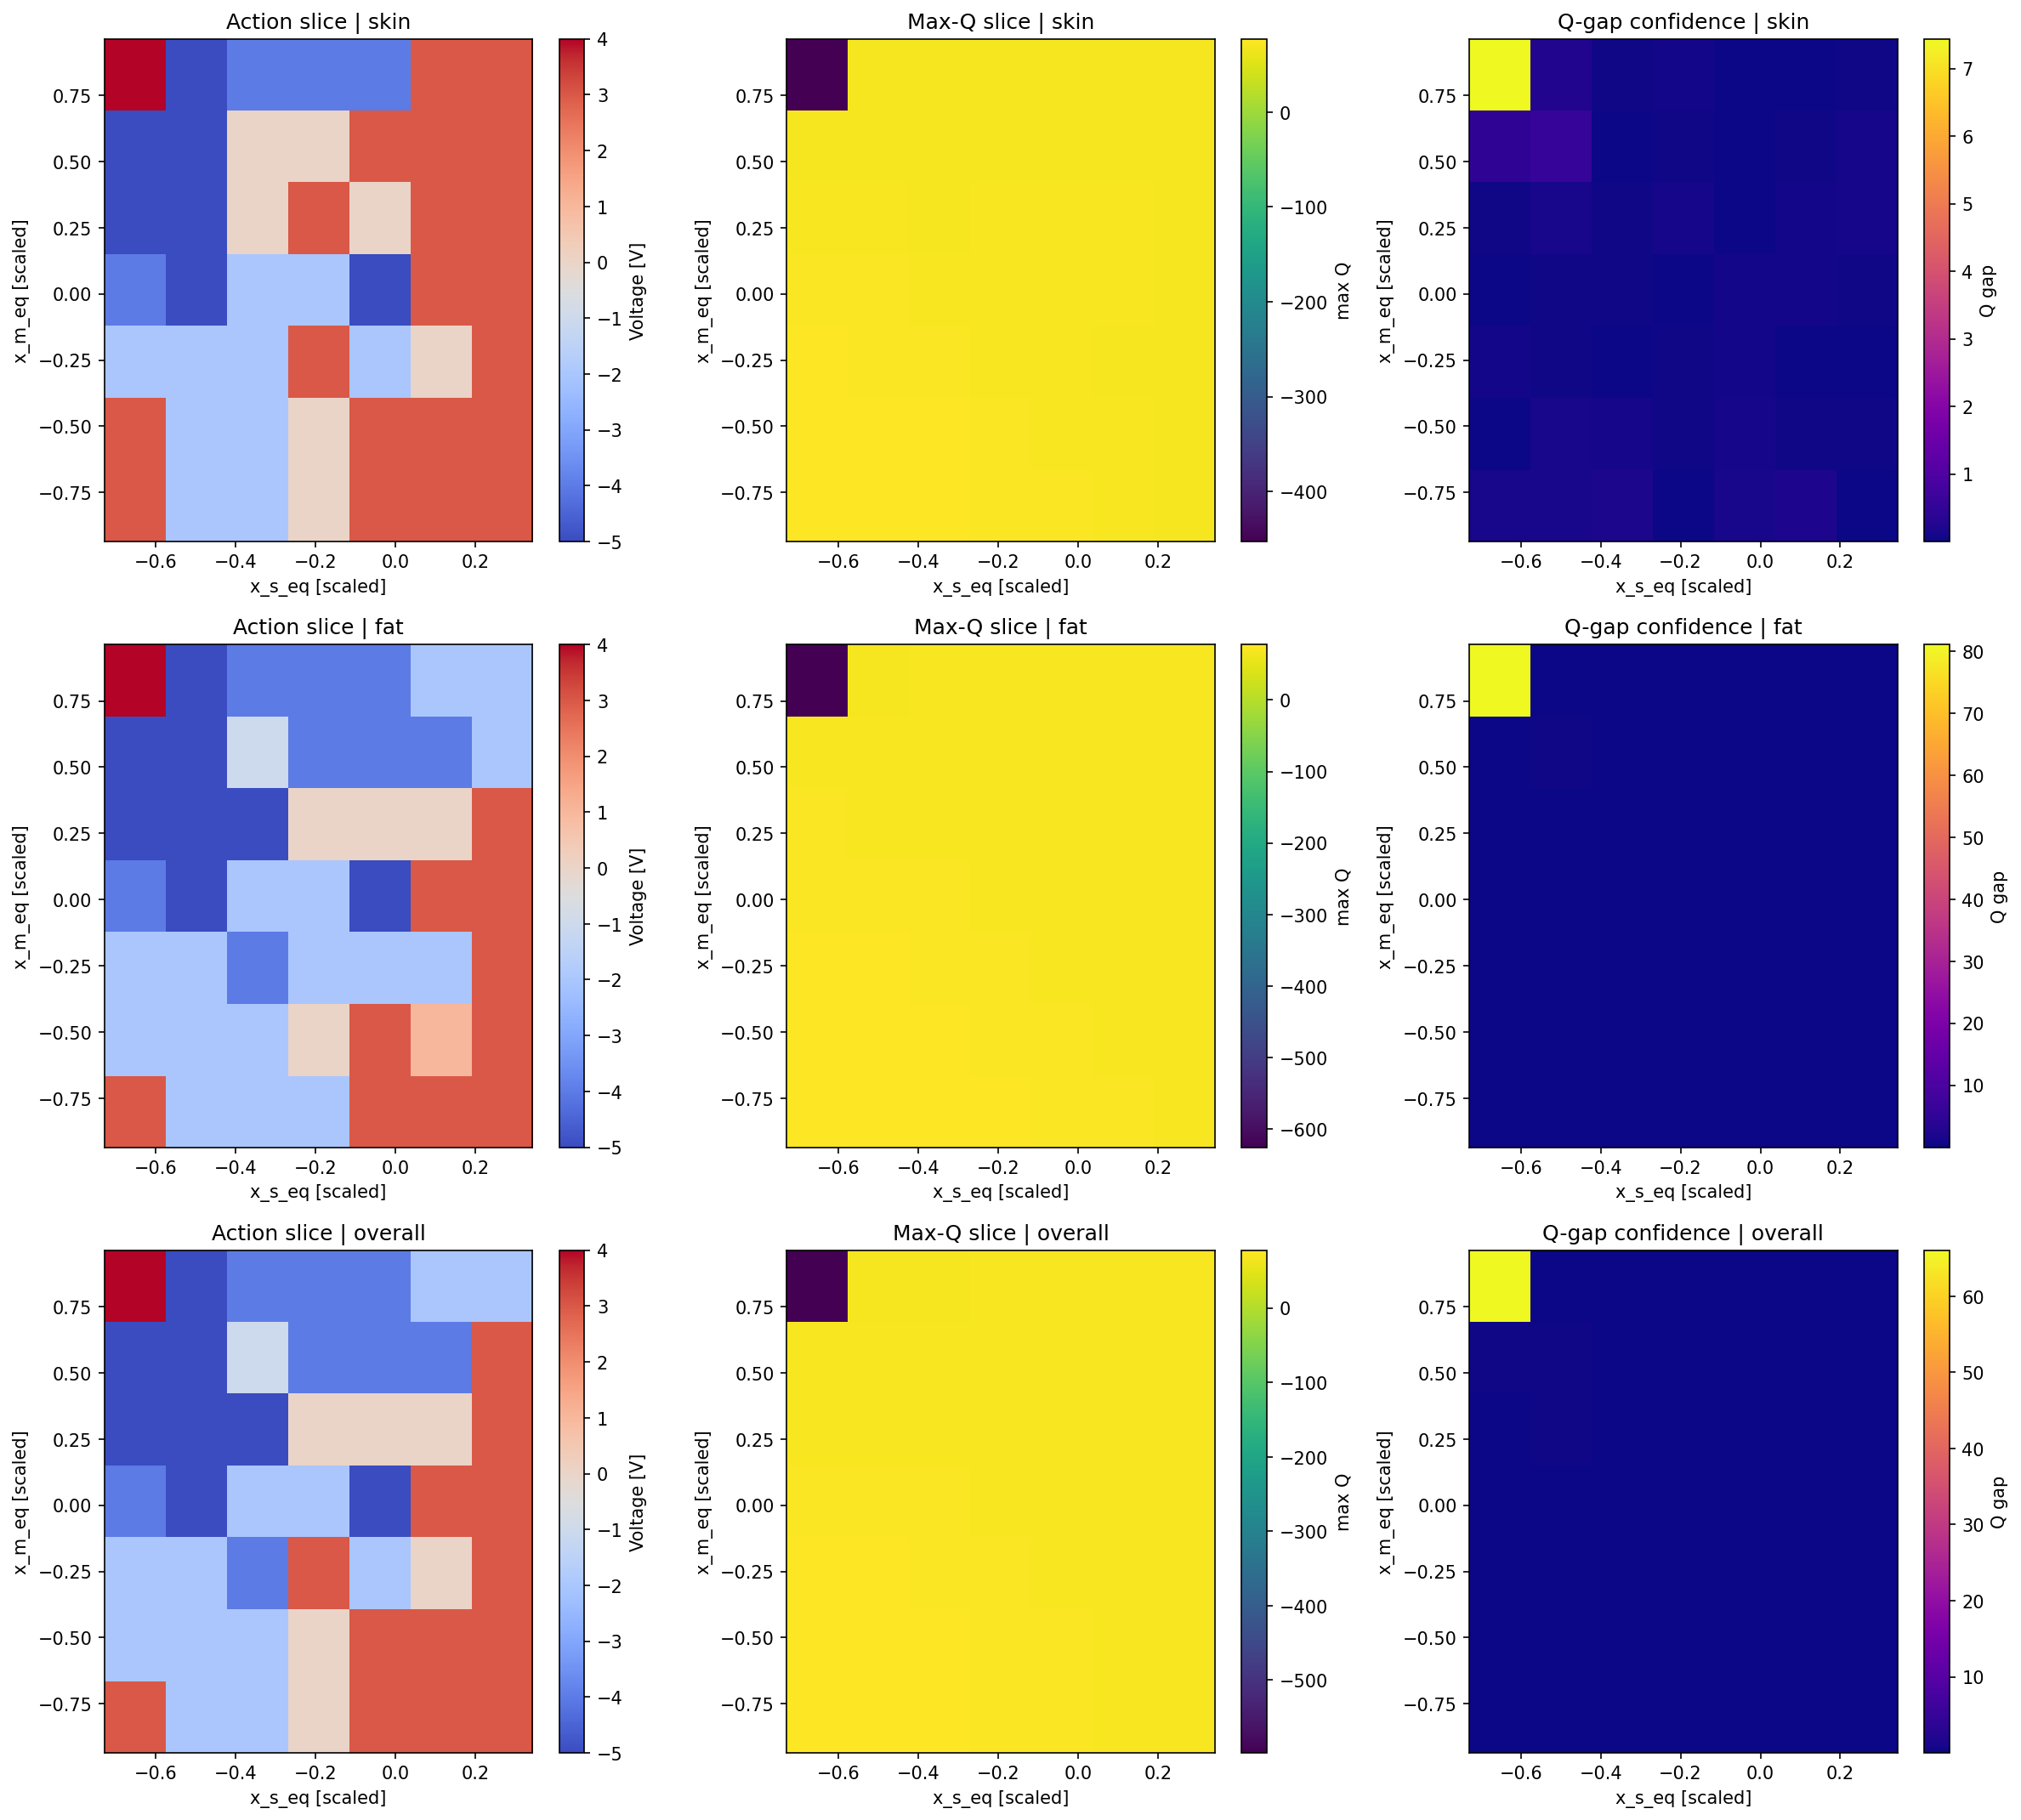

In [6]:
plot_specs = [
    ('train.png', 'Training metrics'),
    ('roll.png', 'Evaluation roll plot'),
    ('act.png', 'Evaluation action plot'),
    ('traj.png', 'Evaluation trajectory plot'),
    ('slices.png', 'Policy slices'),
]

run_root = RUN_ROOTS['dyn']
for filename, title in plot_specs:
    show_image(run_root / 'p' / filename, title=f"{MODE_LABELS['dyn']}: {title}")


### gui_skin_locked

### gui_skin_locked: Training metrics

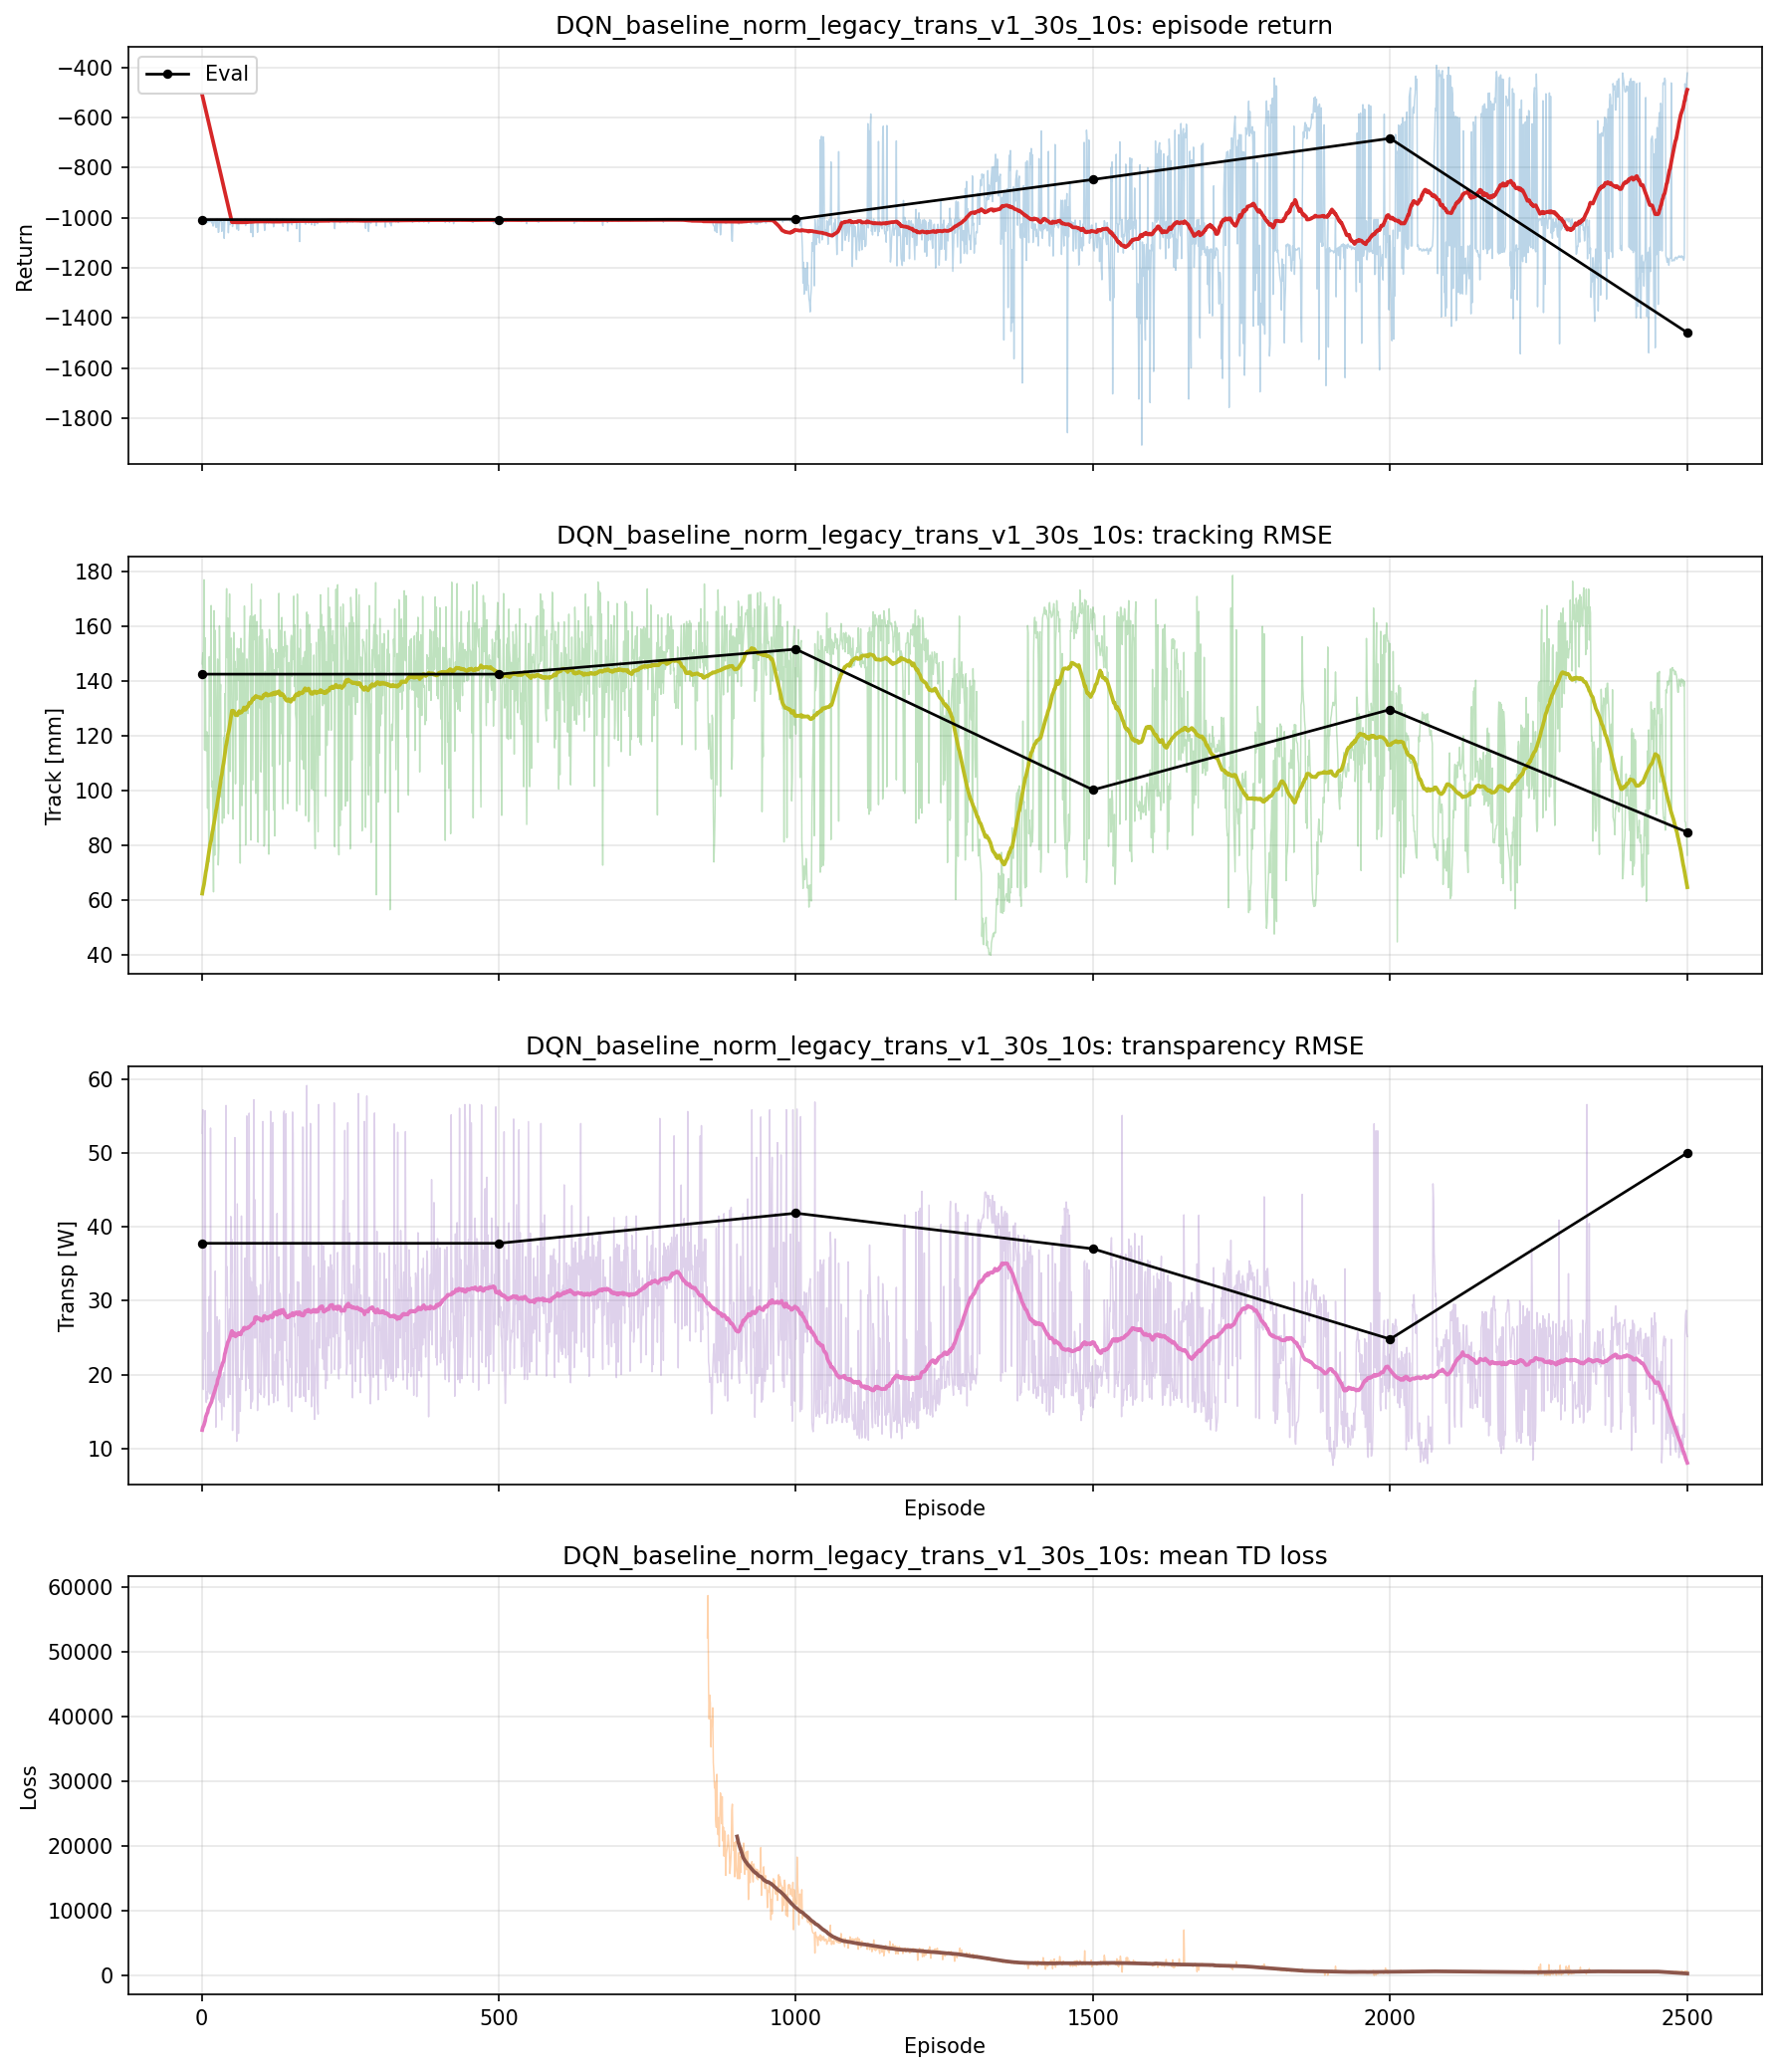

### gui_skin_locked: Evaluation roll plot

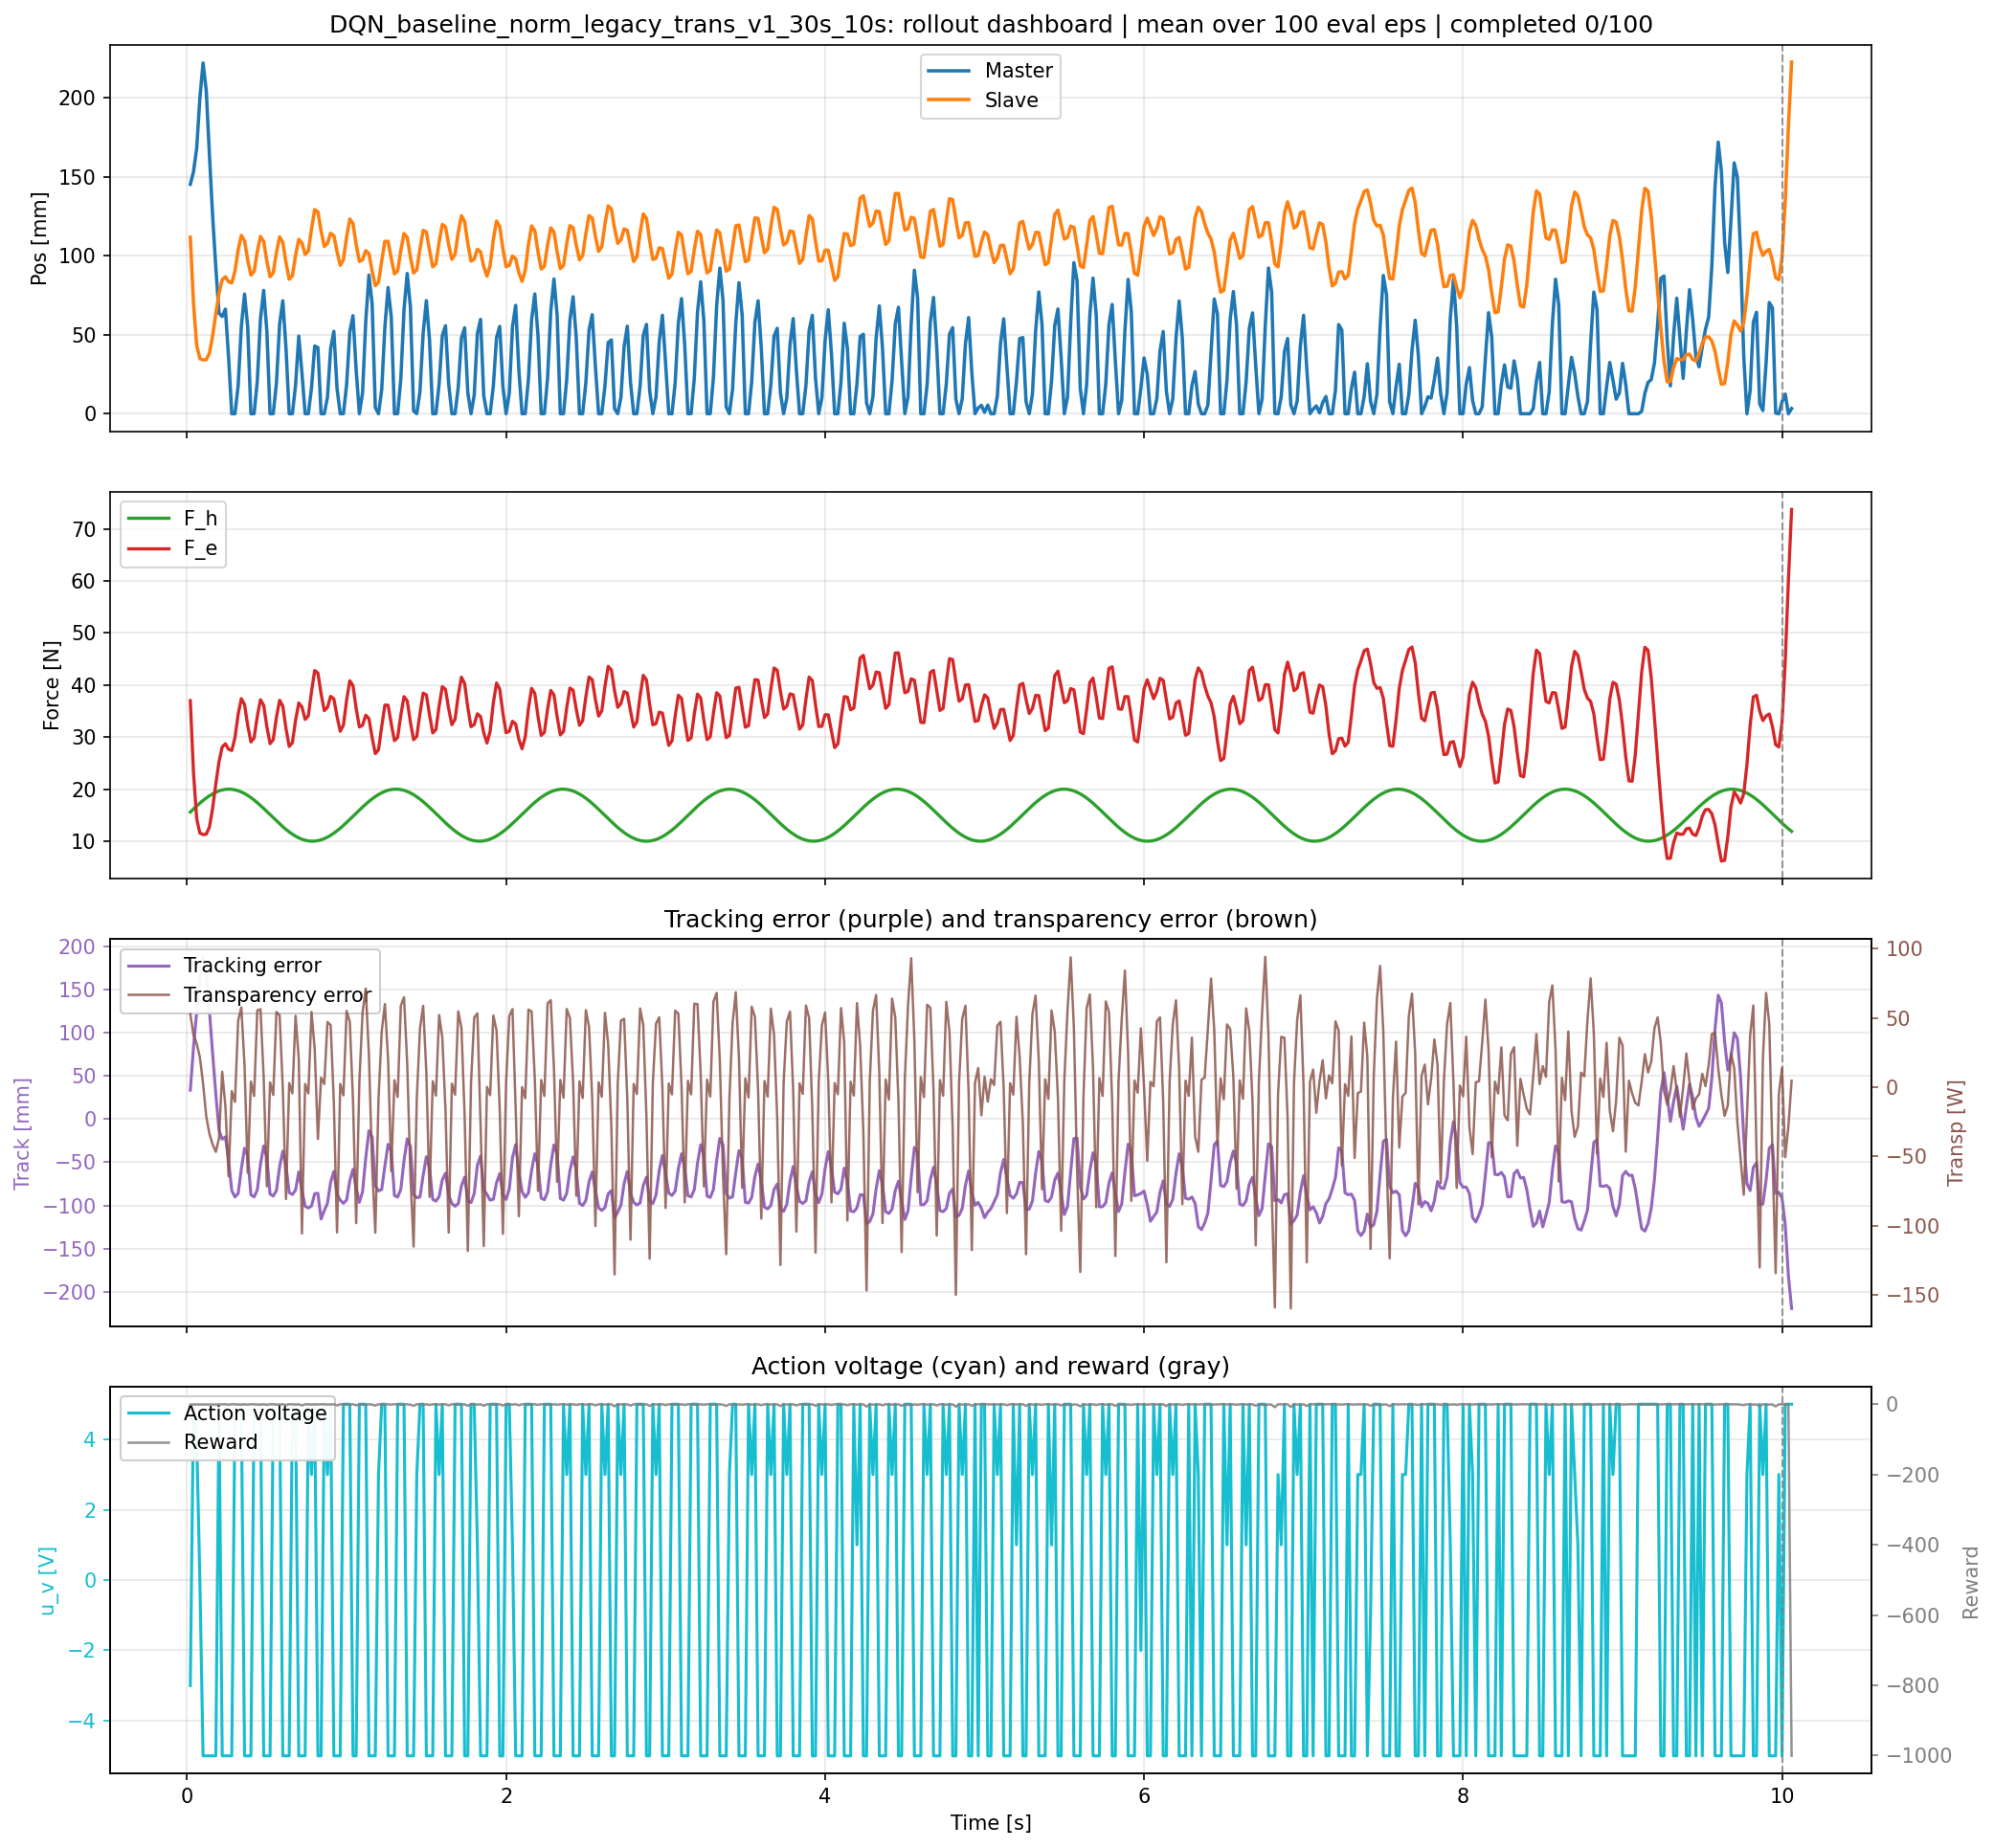

### gui_skin_locked: Evaluation action plot

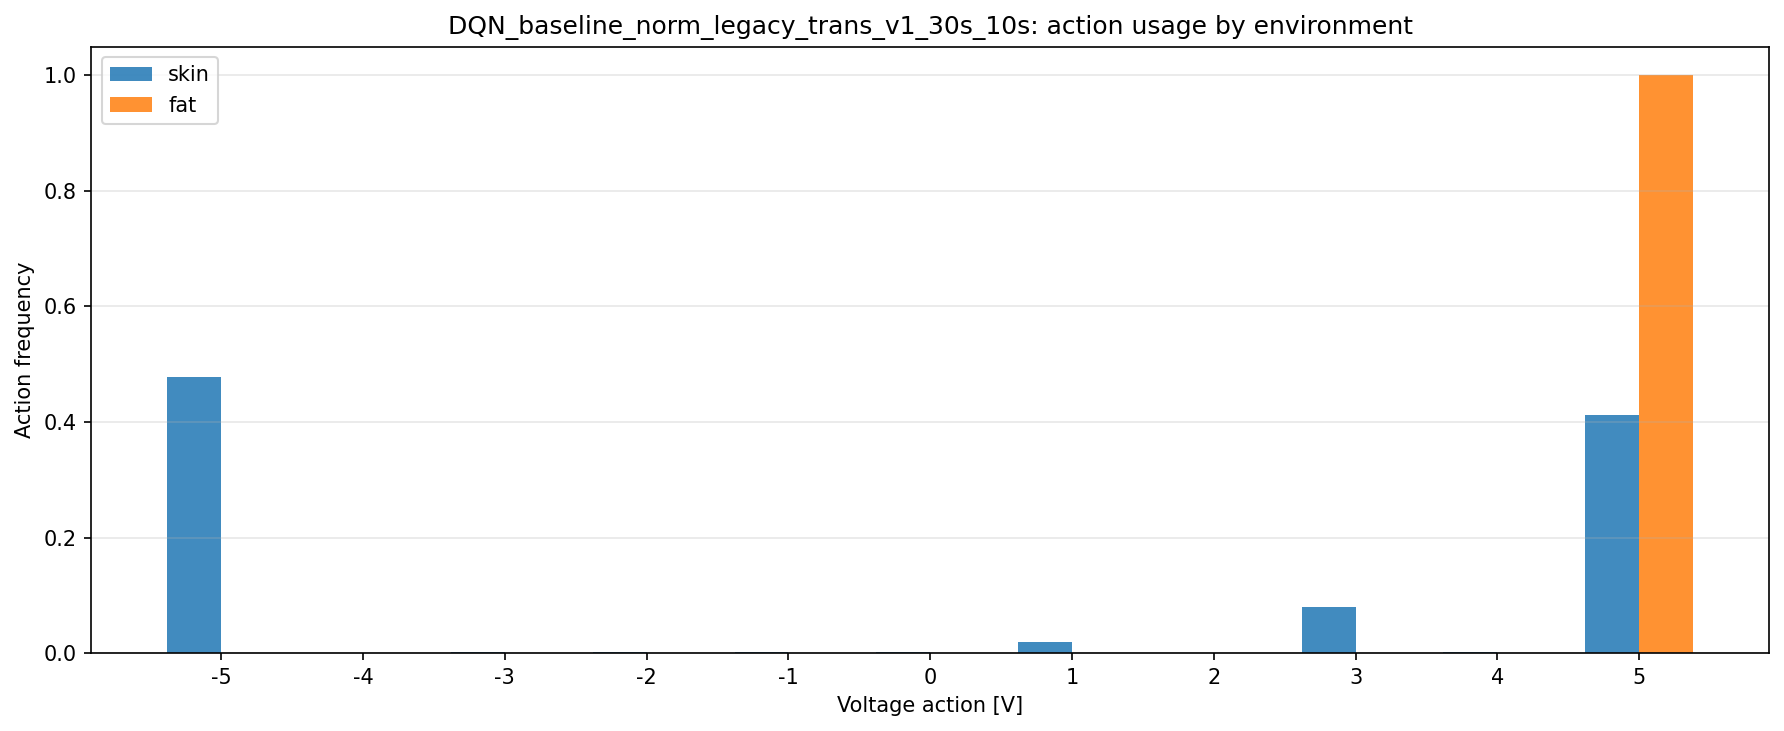

### gui_skin_locked: Evaluation trajectory plot

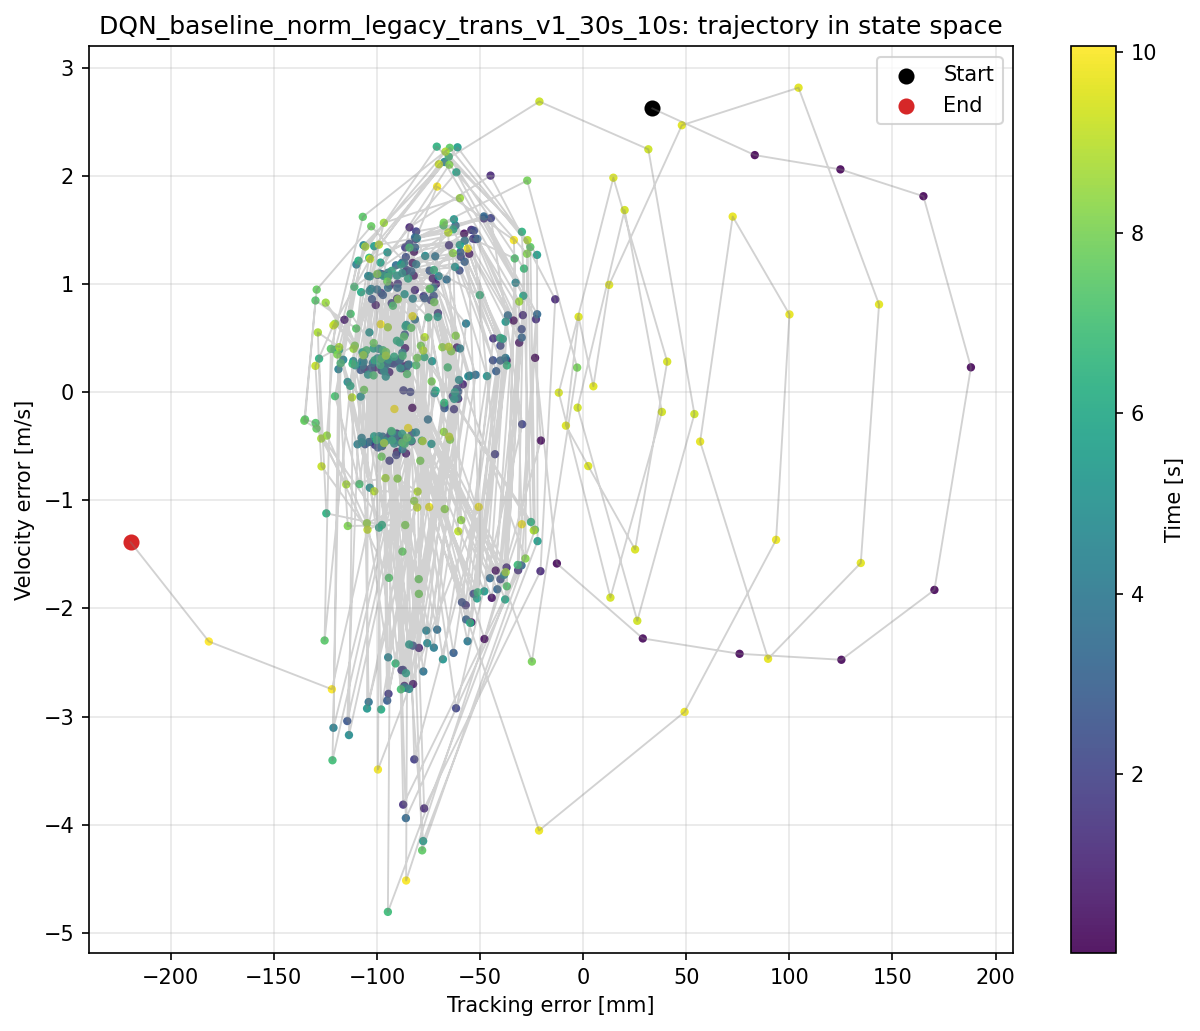

### gui_skin_locked: Policy slices

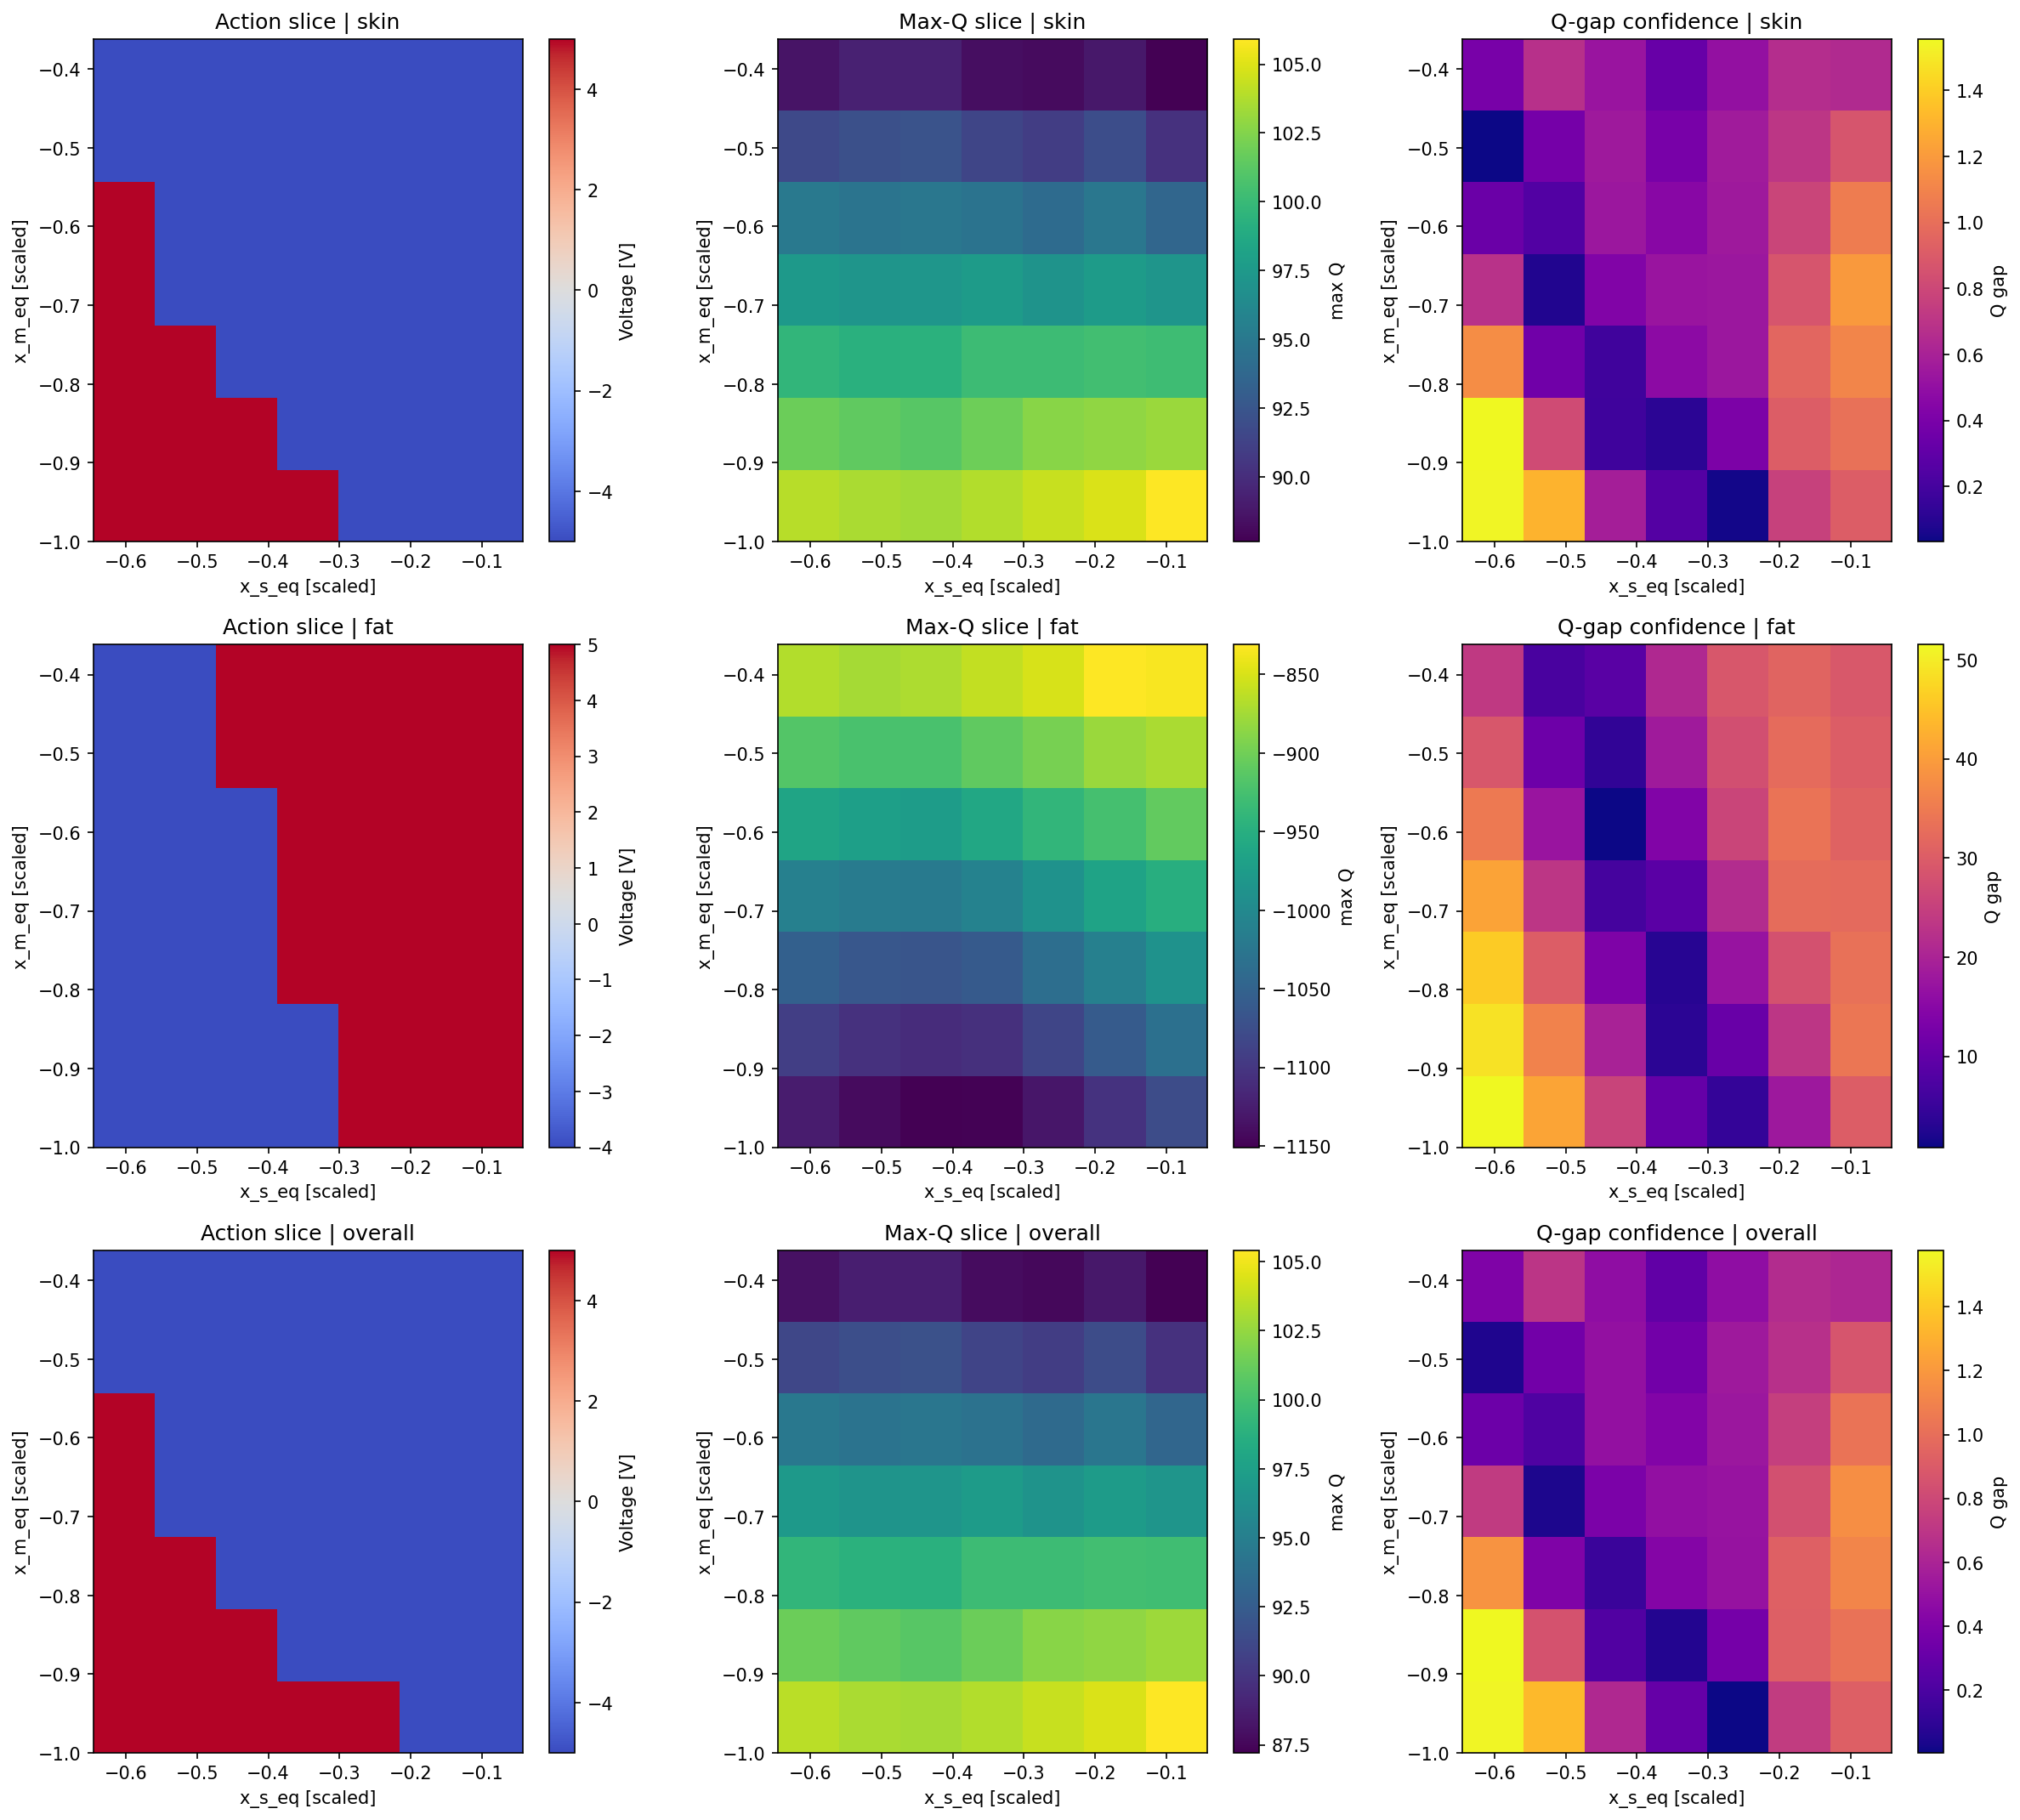

In [7]:
run_root = RUN_ROOTS['gui']
for filename, title in plot_specs:
    show_image(run_root / 'p' / filename, title=f"{MODE_LABELS['gui']}: {title}")
